# Modelowanie
W filtrze antyspamowym głównym celem jest minimalizacja False Positives (sytuacji, w której odcinamy użytkownika od ważnej, prawdziwej wiadomości). Wymaga to skupienia się na metryce Precision (Precyzja).

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import joblib
import time
import os

In [2]:
# Wczytanie ustandaryzowanych danych
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')['target']
y_test = pd.read_csv('../data/processed/y_test.csv')['target']

# Upewnienie się, że folder na modele istnieje
os.makedirs('../models', exist_ok=True)

In [ ]:
# Inicjalizacja modeli badawczych



models = {
    # Modele bazowe (Baselines)
    "Naive Bayes (Gaussian)": GaussianNB(),
    # max_iter=1000 zapobiega błędom braku zbieżności przy optymalizacji
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42), 
    
    # Maszyny Wektorów Nośnych (kernel liniowy i nieliniowy RBF)
    # probability=True pozwoli na wygenerowanie krzywych ROC w kolejnym arkuszu
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    
    # Modele oparte na drzewach decyzyjnych i Gradient Boostingu
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=42, verbose=-1)
}

In [4]:
# Pętla trenująca, testująca i mierząca czas
results = []

print("--- ROZPOCZĘCIE TRENOWANIA ---\n")
print("Uwaga: Trenowanie modeli SVM może potrwać zauważalnie dłużej niż pozostałych.\n")

for name, model in models.items():
    print(f"Trenowanie modelu: {name}...")
    
    # Mierzenie czasu treningu
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    
    # Tworzenie bezpiecznej nazwy pliku i zapis modelu
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    joblib.dump(model, f'../models/{safe_name}.pkl')
    
    # Generowanie predykcji
    y_pred = model.predict(X_test)
    
    # Obliczanie metryk
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Dodanie wyników do zestawienia
    results.append({
        "Model": name,
        "Accuracy (Dokładność)": acc,
        "Precision (Precyzja)": prec,
        "Recall (Czułość)": rec,
        "F1-Score": f1,
        "Czas treningu [s]": round(training_time, 4)
    })

--- ROZPOCZĘCIE TRENOWANIA ---

Uwaga: Trenowanie modeli SVM może potrwać zauważalnie dłużej niż pozostałych.

Trenowanie modelu: Naive Bayes (Gaussian)...
Trenowanie modelu: Logistic Regression...
Trenowanie modelu: SVM (Linear)...


c:\Users\akepk\spam\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Trenowanie modelu: SVM (RBF)...


c:\Users\akepk\spam\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Trenowanie modelu: Random Forest...
Trenowanie modelu: XGBoost...
Trenowanie modelu: LightGBM...


In [5]:
# Agregacja i wyświetlenie wyników
results_df = pd.DataFrame(results)

print("\n--- WYNIKI KLASYFIKACJI (Posortowane po Precyzji) ---")
display(results_df.sort_values(by="Precision (Precyzja)", ascending=False))


--- WYNIKI KLASYFIKACJI (Posortowane po Precyzji) ---


,Model,Accuracy (Dokładność),Precision (Precyzja),Recall (Czułość),F1-Score,Czas treningu [s]
4,Random Forest,0.953627,0.951220,0.931343,0.941176,0.3722
5,XGBoost,0.959572,0.943953,0.955224,0.949555,0.2415
6,LightGBM,0.957194,0.935860,0.958209,0.946903,2.9952
3,SVM (RBF),0.931034,0.918429,0.907463,0.912913,0.7394
1,Logistic Regression,0.923900,0.904478,0.904478,0.904478,0.0157
2,SVM (Linear),0.919144,0.898507,0.898507,0.898507,0.9955
0,Naive Bayes (Gaussian),0.810939,0.686441,0.967164,0.802974,0.2849


### Wnioski
* Random Forest w kontekscie precyzji jest zwyciesca. Oznacza to, że model ten najrzadziej ze wszystkich popełnia tzw. błąd I rodzaju (False Positive) – czyli najrzadziej blokuje prawdziwe, ważne maile. W systemach antyspamowych lepiej jest przepuścić jeden spam do skrzynki odbiorczej, niż usunąć wazny mail.
* XGBoost ma najwyższą Dokładność (Accuracy = 0.959) oraz najwyższy F1-Score (0.949), co oznacza, że najlepiej radzi sobie z ogólnym rozróżnianiem obu klas. Jesli chodzi o precyzje jest na drugim miejscu.
* Naive Bayes jest najlepszy jesli chodzi o czas uczenia i czułość - wyłapuje 97% spamu. Natomiast ma najgorsza precyzje. Wrzucił do spamu mnóstwo normalnych wiadomości, stając się filtrem niezwykle agresywnym. 

## Tuning najlepszych algorytmow
### Tuning Random Forest

In [6]:
from sklearn.model_selection import GridSearchCV

print("--- OPTYMALIZACJA HIPERPARAMETRÓW: RANDOM FOREST ---")

# 1. Definiujemy siatkę parametrów do przetestowania
# Uwaga: Im więcej wartości, tym dłużej potrwa trening!
param_grid_rf = {
    'n_estimators': [100, 200, 300],        # Liczba drzew w lesie
    'max_depth': [None, 10, 20, 30],        # Maksymalna głębokość drzewa
    'min_samples_split': [2, 5, 10],        # Minimalna liczba próbek do podziału węzła
    'min_samples_leaf': [1, 2, 4]           # Minimalna liczba próbek w liściu
}

# 2. Inicjalizujemy bazowy model
rf_base = RandomForestClassifier(random_state=42)

# 3. Konfigurujemy GridSearchCV
# scoring='precision' to kluczowy element - optymalizujemy model pod kątem unikania False Positives
# cv=5 oznacza 5-krotną walidację krzyżową (Cross-Validation)
grid_search_rf = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid_rf, 
    scoring='precision', 
    cv=5, 
    n_jobs=-1, # -1 oznacza użycie wszystkich rdzeni procesora, co znacznie przyspieszy proces
    verbose=1
)

# 4. Uruchamiamy wyszukiwanie najlepszych parametrów
print("Rozpoczynam przeszukiwanie siatki. To może potrwać kilka minut...\n")
grid_search_rf.fit(X_train, y_train)

# 5. Wyciągamy wnioski
print(f"Najlepsze znalezione parametry: {grid_search_rf.best_params_}")
print(f"Najlepszy wynik Precyzji (podczas Cross-Validation): {grid_search_rf.best_score_:.4f}")

# 6. Zapisujemy zoptymalizowany model
best_rf_model = grid_search_rf.best_estimator_
joblib.dump(best_rf_model, '../models/random_forest_tuned.pkl')

# Testujemy zoptymalizowany model na zbiorze testowym
y_pred_tuned = best_rf_model.predict(X_test)
print(f"\nPrecyzja zoptymalizowanego modelu na zbiorze testowym: {precision_score(y_test, y_pred_tuned):.4f}")

--- OPTYMALIZACJA HIPERPARAMETRÓW: RANDOM FOREST ---
Rozpoczynam przeszukiwanie siatki. To może potrwać kilka minut...

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Najlepsze znalezione parametry: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Najlepszy wynik Precyzji (podczas Cross-Validation): 0.9527

Precyzja zoptymalizowanego modelu na zbiorze testowym: 0.9477


#### Wnioski z optymalizacji Random Forest
* Ochrona przed przeuczeniem (Overfittingiem): Zauważ, że algorytm uznał za optymalne ograniczenie głębokości drzew do 10 (max_depth: 10), podczas gdy bazowy model z poprzedniego kroku (domyślne parametry biblioteki) miał głębokość nielimitowaną. Oznacza to, że zoptymalizowany model jest prostszy, bardziej uogólniony i bezpieczniejszy we wdrożeniu produkcyjnym
* Lekki spadek precyzji na zbiorze testowym: W modelu bazowym precyzja wynosiła 0.9512, a po tuningu wyniosła 0.9477.Zoptymalizowany model (który osiągnął precyzję 0.9527 podczas 5-krotnej walidacji krzyżowej) jest po prostu bardziej stabilny przy wielokrotnym przetasowaniu danych.

Optymalizacja hiperparametrów ustabilizowała model, zmniejszając jego złożoność (max_depth=10), co minimalizuje ryzyko przeuczenia kosztem marginalnego spadku precyzji o ułamki procenta na jednym, konkretnym zbiorze testowym

### Tuning XBoost
XGBoost zazwyczaj wykazuje znacznie większą podatność na tuning niż Random Forest, zwłaszcza dzięki parametrom takim jak tempo uczenia (learning_rate) oraz proporcja losowanego podzbioru do budowy drzewa (subsample).

In [ ]:
print("--- OPTYMALIZACJA HIPERPARAMETRÓW: XGBOOST ---")

# 1. Definiujemy siatkę parametrów dla XGBoost
param_grid_xgb = {
    'max_depth': [3, 5, 6, 7],                 # Głębokość pojedynczego drzewa
    'learning_rate': [0.01, 0.05, 0.1],     # Szybkość uczenia
    'n_estimators': [100, 200, 300],        # Liczba iteracji (drzew)
    'subsample': [0.8, 1.0]                 # 0.8 oznacza, że każde drzewo uczy się na 80% losowych wierszy (chroni przed overfittingiem)
}

# 2. Inicjalizujemy bazowy model
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Konfigurujemy GridSearchCV (również skupiamy się na Precyzji)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid_xgb, 
    scoring='precision', 
    cv=5, 
    n_jobs=-1, 
    verbose=1
)

# 4. Uruchamiamy wyszukiwanie (to również potrwa chwilę)
print("Rozpoczynam przeszukiwanie siatki dla XGBoost...\n")
grid_search_xgb.fit(X_train, y_train)

# 5. Wyświetlamy wyniki
print(f"Najlepsze znalezione parametry: {grid_search_xgb.best_params_}")
print(f"Najlepszy wynik Precyzji (podczas Cross-Validation): {grid_search_xgb.best_score_:.4f}")

# 6. Zapisujemy zoptymalizowany model
best_xgb_model = grid_search_xgb.best_estimator_
joblib.dump(best_xgb_model, '../models/xgboost_tuned.pkl')

# 7. Testujemy na zbiorze testowym
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
print(f"\nPrecyzja zoptymalizowanego modelu na zbiorze testowym: {precision_score(y_test, y_pred_xgb_tuned):.4f}")

SyntaxError: invalid syntax (2335878379.py, line 5)

Wnioski z optymalizacji XGBoost 

* Działanie regularyzacji (Subsampling): Algorytm optymalizacyjny wybrał parametr subsample: 0.8. Oznacza to, że każde kolejne drzewo w modelu uczyło się tylko na losowych 80% próbek ze zbioru treningowego. Wprowadza to celowy, kontrolowany "szum", który zmusza model do uogólniania wiedzy, zamiast uczenia się na pamięć konkretnych wierszy.

* Wolniejsza, ale stabilniejsza nauka: Wybrany learning_rate: 0.01 to bardzo ostrożny, zachowawczy krok (domyślnie XGBoost używa często 0.1 lub 0.3). Model robi mniejsze modyfikacje wag w każdej iteracji. W połączeniu z nieznacznie głębszymi drzewami (max_depth: 7) daje to precyzyjny, stabilny mechanizm.

 * Realistyczna ocena modelu (Cross-Validation vs Test): Najważniejszą liczbą z Twojego wyniku nie jest ostateczne 0.9393, ale wynik z walidacji krzyżowej (CV): 0.9470. Ponieważ siatka (GridSearchCV) uśredniła ten wynik z pięciu różnych podziałów zbioru, jest to najbardziej obiektywna i wiarygodna miara tego, jak XGBoost radzi sobie ze zbiorem Spambase. Wyższy wynik z wcześniejszego kroku (0.9439) na domyślnych parametrach mógł być po prostu łutem szczęścia wynikającym z jednego, konkretnego podziału danych przez train_test_split.

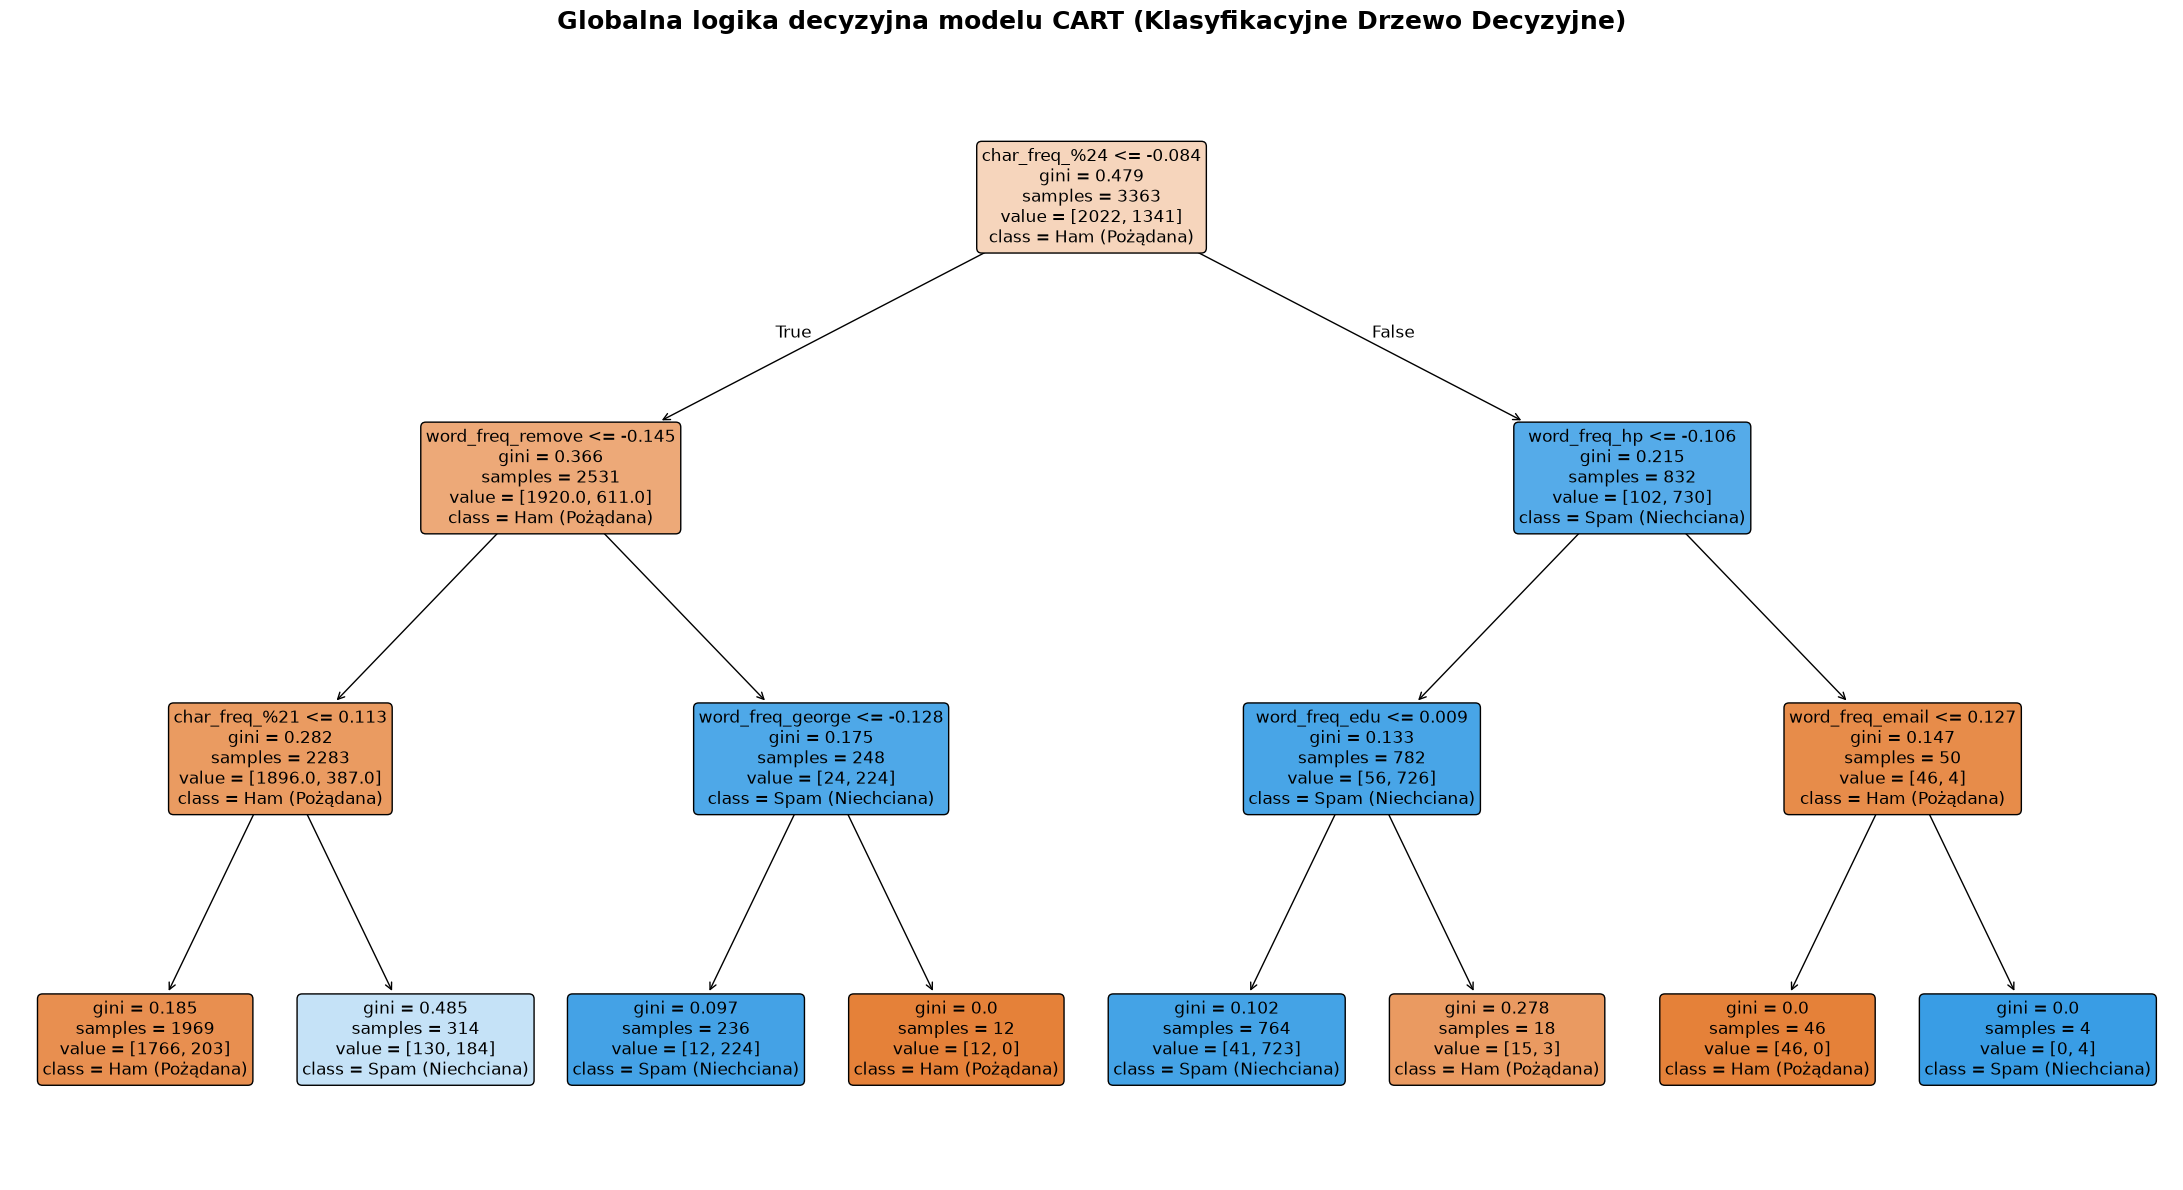

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd

# 1. Wczytanie danych treningowych
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')['target']

# 2. Inicjalizacja i trening GLOBALNEGO, czystego Drzewa Decyzyjnego
# Ustawiamy max_depth=3, aby drzewo zmieściło się na stronie i było czytelne
global_tree = DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini')
global_tree.fit(X_train, y_train)

# 3. Generowanie wykresu
plt.figure(figsize=(22, 12)) 

plot_tree(global_tree, 
          feature_names=X_train.columns, 
          class_names=['Ham (Pożądana)', 'Spam (Niechciana)'], 
          filled=True, 
          rounded=True, 
          fontsize=12,
          proportion=False,
          precision=3)

plt.title("Globalna logika decyzyjna modelu CART (Klasyfikacyjne Drzewo Decyzyjne)", 
          fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('07_globalne_drzewo_decyzyjne.png', dpi=300, bbox_inches='tight')
plt.show()